# Atividade 1 — Processamento de Linguagem Natural (PLN)

Esta atividade reúne seis exercícios em Python sobre validação e extração de informações em textos. Serão abordadas a verificação de senhas, a validação de endereços de e-mail e a extração de dados de referências de livros, além da análise do comprimento, do pré-processamento e da representação de tweets por contagens de palavras, com uso de expressões regulares nas questões 2 e 3. A última questão aprofunda o pré-processamento com remoção de stopwords, rotulação gramatical (POS) e stemização. Cada questão apresenta o enunciado, a implementação e exemplos de uso.

**Integrantes:**

- José Anderson da Silva
- Otto Tenório de Albuquerque Lins Bisneto


# Questão 1 — Verificação de senha forte

**Enunciado:** Escreva uma função que receba uma senha como entrada e verifique se ela atende aos seguintes critérios de uma senha forte:

- Pelo menos 8 caracteres;
- Pelo menos uma letra maiúscula e uma letra minúscula;
- Pelo menos um dígito;
- Pelo menos um caractere especial (por exemplo, `!@#$%&*`).

A função deve retornar `True` se a senha for forte e `False` caso contrário. Mostre exemplos.

**Sobre a implementação:**

A função recebe uma senha e retorna `True` se ela tiver pelo menos 8 caracteres, uma letra maiúscula, uma minúscula, um dígito e um caractere especial. Caso contrário, retorna `False`.

Aqui, os caracteres especiais são os sinais de pontuação de `string.punctuation`, como `!@#$%&*`. Espaços não contam como caracteres especiais. Não é necessária uma base de dados.


In [1]:
import string

def senha_forte(senha):
    # any retorna True se pelo menos um caractere atender à condição.
    tamanho_valido = len(senha) >= 8
    tem_maiuscula = any(c.isupper() for c in senha)
    tem_minuscula = any(c.islower() for c in senha)
    tem_digito = any(c.isdigit() for c in senha)
    tem_especial = any(c in string.punctuation for c in senha)

    # Todos os critérios precisam ser atendidos ao mesmo tempo.
    return (tamanho_valido and tem_maiuscula and tem_minuscula
            and tem_digito and tem_especial)

In [2]:
# Senhas fictícias para mostrar e verificar o resultado da função.
exemplos = [
    ('Abcdef1!', True, 'Atende a todos os critérios; tem exatamente 8 caracteres'),
    ('EstudoPLN2026@', True, 'Atende a todos os critérios'),
    ('Abcd1!x', False, 'Tem apenas 7 caracteres'),
    ('abcdef1!', False, 'Falta letra maiúscula'),
    ('ABCDEF1!', False, 'Falta letra minúscula'),
    ('Abcdefg!', False, 'Falta dígito'),
    ('Abcdef12', False, 'Falta caractere especial'),
    ('Abcdef1 ', False, 'Espaço não conta como caractere especial'),
    ('', False, 'Senha vazia'),
]

for senha, esperado, motivo in exemplos:
    resultado = senha_forte(senha)
    print(f'{senha!r}: {resultado} — {motivo}')
    assert resultado == esperado, f'Resultado inesperado para {senha!r}'

print('Todos os exemplos passaram na verificação.')

'Abcdef1!': True — Atende a todos os critérios; tem exatamente 8 caracteres
'EstudoPLN2026@': True — Atende a todos os critérios
'Abcd1!x': False — Tem apenas 7 caracteres
'abcdef1!': False — Falta letra maiúscula
'ABCDEF1!': False — Falta letra minúscula
'Abcdefg!': False — Falta dígito
'Abcdef12': False — Falta caractere especial
'Abcdef1 ': False — Espaço não conta como caractere especial
'': False — Senha vazia
Todos os exemplos passaram na verificação.


# Questão 2 — Validação de e-mail

**Enunciado:** Escreva uma função que receba um endereço de e-mail como entrada e verifique se ele é válido de acordo com as regras básicas de formação de um e-mail. Utilize expressões regulares para realizar a validação. A função deve retornar `True` se o endereço de e-mail for válido e `False` caso contrário. Mostre exemplos.

**Sobre a implementação:**

A função usa expressões regulares e retorna `True` ou `False`.

Para esta validação básica, aceitamos letras, números e os símbolos `._%+-` antes do `@`, sem pontos consecutivos nem nas extremidades. O domínio deve ter partes separadas por ponto, sem hífen nas extremidades, e uma extensão final com pelo menos duas letras. Essa verificação analisa o formato; não verifica se a caixa de e-mail existe.


In [3]:
import re

def email_valido(email):
    usuario = r'[A-Za-z0-9_%+-]+(?:\.[A-Za-z0-9_%+-]+)*'
    parte_dominio = r'[A-Za-z0-9](?:[A-Za-z0-9-]*[A-Za-z0-9])?'
    padrao = usuario + r'@(?:' + parte_dominio + r'\.)+[A-Za-z]{2,}'
    # fullmatch exige que o endereço inteiro corresponda ao padrão.
    return re.fullmatch(padrao, email) is not None


In [4]:
exemplos_email = [
    ('ana@example.com', True),
    ('ana.silva+pln@example.com.br', True),
    ('aluno@sub.example.org', True),
    ('anaexample.com', False),
    ('ana@@example.com', False),
    ('.ana@example.com', False),
    ('ana..silva@example.com', False),
    ('ana@-example.com', False),
    ('ana@example', False),
    ('ana silva@example.com', False),
    ('', False),
]

for email, esperado in exemplos_email:
    resultado = email_valido(email)
    print(f'{email!r}: {resultado}')
    assert resultado == esperado

print('Todos os exemplos de e-mail passaram.')


'ana@example.com': True
'ana.silva+pln@example.com.br': True
'aluno@sub.example.org': True
'anaexample.com': False
'ana@@example.com': False
'.ana@example.com': False
'ana..silva@example.com': False
'ana@-example.com': False
'ana@example': False
'ana silva@example.com': False
'': False
Todos os exemplos de e-mail passaram.


# Questão 3 — Extração de referência de livro

**Enunciado:** Considere o seguinte exemplo de referência de livro em formato de citação APA:

> Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press.

Implemente uma função usando expressões regulares que extraia cada autor, ano de publicação, título e editora do livro, para qualquer referência de livro neste formato.

**Sobre a implementação:**

A função usa expressões regulares para extrair **cada autor**, **ano**, **título** e **editora**, retornando um dicionário.

Formato considerado: `Sobrenome, I. I., & Sobrenome, I. (AAAA). Título. Editora.` Os autores têm sobrenome e iniciais, e o último pode ser precedido por `&`. A função também aceita um único autor e quebras de linha. Preservamos os autores repetidos do exemplo fornecido.

O último ponto seguido de espaço separa o título da editora; portanto, a editora deve estar sem pontos internos. Este exercício cobre o formato apresentado, não todas as variações de referências APA. Uma entrada fora do formato gera `ValueError`.


In [5]:
import re

def extrair_referencia(referencia):
    # Uniformiza espaços e quebras de linha antes da extração.
    referencia = re.sub(r'\s+', ' ', referencia).strip()
    padrao = (
        r'(?P<autores>.+?)\s*\((?P<ano>[0-9]{4})\)\.\s+'
        r'(?P<titulo>.+)\.\s+(?P<editora>[^.]+)\.'
    )
    resultado = re.fullmatch(padrao, referencia)
    if resultado is None:
        raise ValueError('Referência fora do formato esperado.')

    # Uma inicial é uma letra seguida de ponto.
    inicial = r'[^\W\d_]\.'
    autor = r'[^,;&()]+,\s*' + inicial + r'(?:\s*' + inicial + r')*'
    separador = r'\s*(?:,\s*(?:&\s*)?|&\s*)'
    bloco_autores = resultado.group('autores').strip()
    if re.fullmatch(autor + r'(?:' + separador + autor + r')*', bloco_autores) is None:
        raise ValueError('Autores devem ter sobrenome e iniciais.')

    autores = [a.strip() for a in re.findall(autor, bloco_autores)]
    return {
        'autores': autores,
        'ano': int(resultado.group('ano')),
        'titulo': resultado.group('titulo').strip(),
        'editora': resultado.group('editora').strip(),
    }


In [6]:
from pprint import pprint

referencia = (
    'Manning, C. D., Manning, C. D., & Schutze, H. (1999). '
    'Foundations of statistical natural language processing. MIT press.'
)
dados = extrair_referencia(referencia)
pprint(dados, sort_dicts=False)
assert dados == {
    'autores': ['Manning, C. D.', 'Manning, C. D.', 'Schutze, H.'],
    'ano': 1999,
    'titulo': 'Foundations of statistical natural language processing',
    'editora': 'MIT press',
}

# Referências fictícias para testar outras quantidades de autores.
assert extrair_referencia('Silva, A. (2024). Introdução ao PLN. Editora Exemplo.') == {
    'autores': ['Silva, A.'], 'ano': 2024,
    'titulo': 'Introdução ao PLN', 'editora': 'Editora Exemplo',
}
assert extrair_referencia(
    'Silva, A., & Souza, B. C. (2023). Linguagem e dados. Editora Exemplo.'
)['autores'] == ['Silva, A.', 'Souza, B. C.']

try:
    extrair_referencia('Referência sem o formato solicitado')
except ValueError as erro:
    print('Exemplo inválido:', erro)
else:
    raise AssertionError('A referência inválida deveria ser rejeitada.')

print('Todos os exemplos de referências passaram.')


{'autores': ['Manning, C. D.', 'Manning, C. D.', 'Schutze, H.'],
 'ano': 1999,
 'titulo': 'Foundations of statistical natural language processing',
 'editora': 'MIT press'}
Exemplo inválido: Referência fora do formato esperado.
Todos os exemplos de referências passaram.


# Questão 4 — Distribuição dos comprimentos dos textos

**Enunciado:** Usando sua base de textos, determine a distribuição de comprimentos dos textos (em quantidade de palavras), listando estas quantidades e plotando um histograma.

**Base de dados:** arquivo `Tweets.csv`, da base [Twitter US Airline Sentiment no Kaggle](https://www.kaggle.com/datasets/drnimishadavis/twitter-us-airline-sentiment), fornecido para esta atividade. Usaremos a coluna `text`, que contém os tweets.

**Sobre a implementação:** o comprimento é a quantidade de elementos obtidos com `texto.split()`, que separa o texto por espaços em branco, incluindo quebras de linha. Menções, hashtags, URLs e símbolos isolados também contam como elementos; não removemos pontuação, palavras ou registros duplicados. Textos ausentes ou vazios são excluídos da análise e sua quantidade é informada.

A análise lista as contagens por tweet em uma tabela e salva a listagem completa em `resultados/comprimentos_tweets.csv`. Também mostra a frequência de cada comprimento e um histograma com uma barra por quantidade inteira de palavras.

**No Google Colab:** execute a próxima célula e selecione `Tweets.csv` quando solicitado. Se o arquivo já estiver em `dados/Tweets.csv` ou na pasta atual, ele será carregado diretamente. Os arquivos gerados ficam na pasta `resultados`, acessível pelo painel de arquivos do Colab.


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

caminho_base = next(
    (p for p in [Path('dados/Tweets.csv'), Path('Tweets.csv')] if p.is_file()),
    None,
)
if caminho_base is not None:
    tweets = pd.read_csv(caminho_base, dtype={'tweet_id': 'string'})
else:
    # No Colab, permite selecionar o CSV no computador.
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError('Coloque Tweets.csv na pasta dados ou ao lado do notebook.')
    from io import BytesIO
    enviados = files.upload()
    if 'Tweets.csv' not in enviados:
        raise FileNotFoundError('Selecione o arquivo Tweets.csv e execute novamente.')
    tweets = pd.read_csv(BytesIO(enviados['Tweets.csv']), dtype={'tweet_id': 'string'})

if 'text' not in tweets.columns:
    raise ValueError('A base precisa conter a coluna text.')

textos = tweets['text'].astype('string')
validos = textos.notna() & textos.str.strip().ne('').fillna(False)
colunas = [c for c in ['tweet_id', 'text'] if c in tweets.columns]
contagens = tweets.loc[validos, colunas].copy()
contagens['quantidade_palavras'] = textos.loc[validos].str.split().str.len().astype(int)
if contagens.empty:
    raise ValueError('Não há textos preenchidos para analisar.')

print(f'Registros na base: {len(tweets)}')
print(f'Textos analisados: {len(contagens)}')
print(f'Textos ausentes ou vazios excluídos: {int((~validos).sum())}')
display(contagens)

pasta_resultados = Path('resultados')
pasta_resultados.mkdir(exist_ok=True)
contagens.to_csv(pasta_resultados / 'comprimentos_tweets.csv', index=False, encoding='utf-8-sig')
print('Listagem completa salva em resultados/comprimentos_tweets.csv')


Registros na base: 14640
Textos analisados: 14640
Textos ausentes ou vazios excluídos: 0


,tweet_id,text,quantidade_palavras
0,570306133677760513,@VirginAmerica What @dhepburn said.,4
1,570301130888122368,@VirginAmerica plus you've added commercials t...,9
2,570301083672813571,@VirginAmerica I didn't today... Must mean I n...,12
3,570301031407624196,@VirginAmerica it's really aggressive to blast...,17
4,570300817074462722,@VirginAmerica and it's a really big bad thing...,10
...,...,...,...
14635,569587686496825344,@AmericanAir thank you we got on a different f...,11
14636,569587371693355008,@AmericanAir leaving over 20 minutes Late Flig...,23
14637,569587242672398336,@AmericanAir Please bring American Airlines to...,7
14638,569587188687634433,"@AmericanAir you have my money, you change my ...",23


Listagem completa salva em resultados/comprimentos_tweets.csv


In [8]:
comprimentos = contagens['quantidade_palavras']
# Inclui comprimentos intermediários com frequência zero, caso existam.
frequencias = comprimentos.value_counts().reindex(
    range(int(comprimentos.min()), int(comprimentos.max()) + 1), fill_value=0
).sort_index()
distribuicao = frequencias.rename_axis('quantidade_palavras').reset_index(name='quantidade_textos')
distribuicao['percentual'] = distribuicao['quantidade_textos'] / len(contagens) * 100
print(distribuicao.to_string(index=False, formatters={'percentual': '{:.2f}%'.format}))
distribuicao.to_csv(pasta_resultados / 'distribuicao_comprimentos.csv', index=False, encoding='utf-8-sig')

print(f'\nMínimo: {comprimentos.min()} palavras')
print(f'Máximo: {comprimentos.max()} palavras')
print(f'Média: {comprimentos.mean():.2f} palavras')
print(f'Mediana: {comprimentos.median():.1f} palavras')
print('Comprimento(s) mais frequente(s):', comprimentos.mode().tolist())
assert distribuicao['quantidade_textos'].sum() == len(contagens)


 quantidade_palavras  quantidade_textos percentual
                   2                120      0.82%
                   3                200      1.37%
                   4                241      1.65%
                   5                270      1.84%
                   6                308      2.10%
                   7                375      2.56%
                   8                411      2.81%
                   9                426      2.91%
                  10                389      2.66%
                  11                476      3.25%
                  12                477      3.26%
                  13                511      3.49%
                  14                529      3.61%
                  15                517      3.53%
                  16                618      4.22%
                  17                577      3.94%
                  18                604      4.13%
                  19                668      4.56%
                  20           

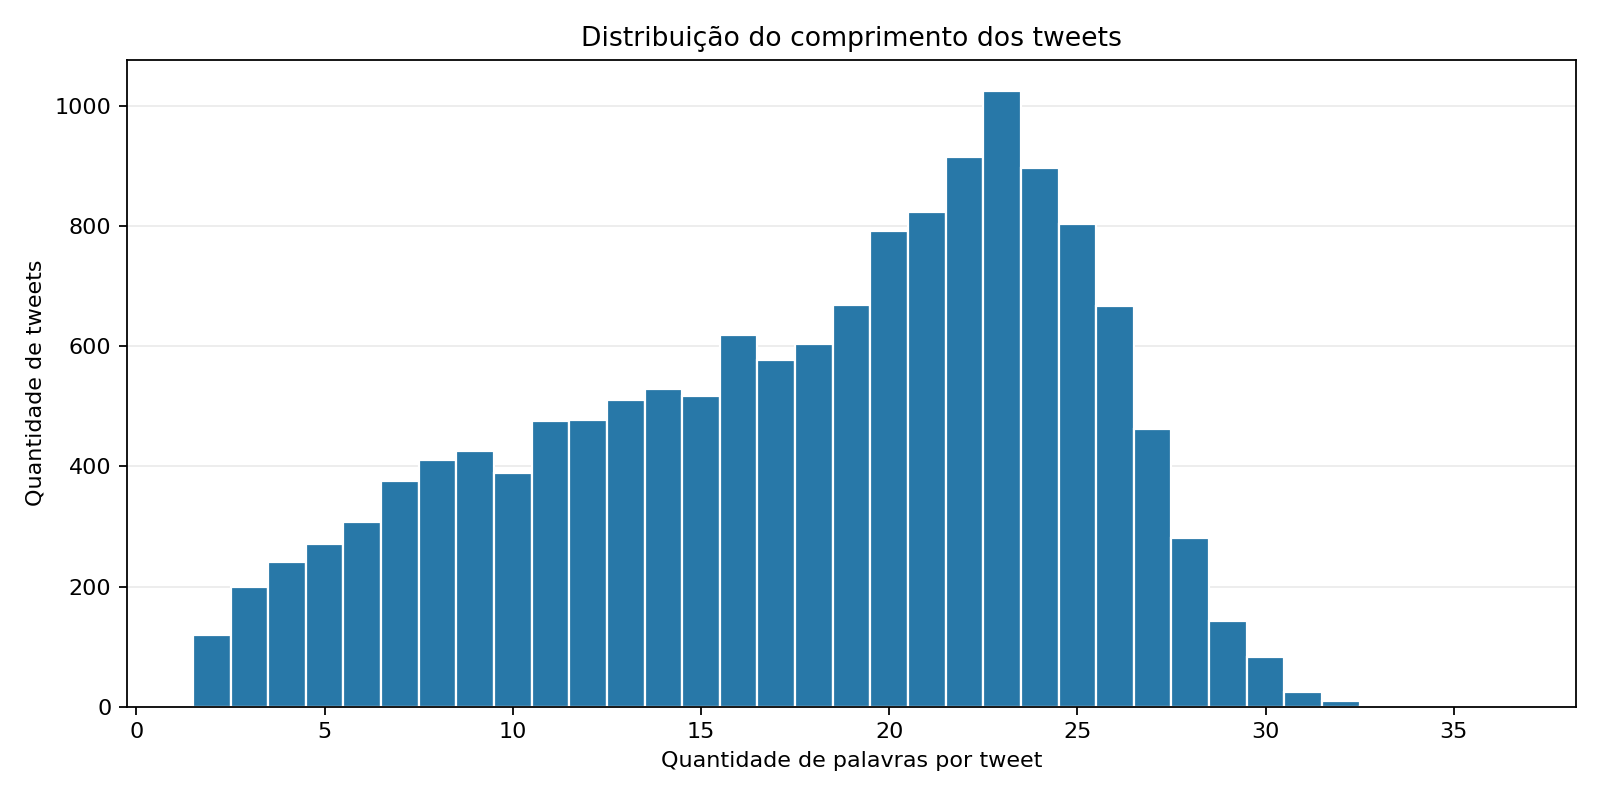

In [9]:
# Bordas deslocadas em 0,5 centralizam as barras nos valores inteiros.
bordas = [n - 0.5 for n in range(int(comprimentos.min()), int(comprimentos.max()) + 2)]
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(comprimentos, bins=bordas, color='#2878A8', edgecolor='white')
ax.set_title('Distribuição do comprimento dos tweets')
ax.set_xlabel('Quantidade de palavras por tweet')
ax.set_ylabel('Quantidade de tweets')
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(pasta_resultados / 'histograma_comprimentos.png', dpi=160)
plt.show()


# Questão 5 — Pré-processamento e representação dos textos

**Enunciado:** Aplique os seguintes passos de pré-processamento aos textos:

- Remova todas as palavras que contêm números;
- Converta as palavras para minúsculas;
- Remova pontuação;
- Tokenize os textos em palavras, gerando um dicionário único com $n$ tokens e convertendo cada texto em um vetor de dimensão $n$ com a respectiva contagem de palavras.

Em seguida, encontre as 10 palavras mais frequentes da base de textos.

**Sobre a implementação:** usamos os tweets carregados na Questão 4. Primeiro, separamos por espaços em branco e descartamos cada elemento que contenha algum dígito: por exemplo, `voo123` é removido inteiro. Depois, convertemos para minúsculas, apagamos os sinais de pontuação e fazemos a tokenização final por espaços. A pontuação inclui os caracteres de `string.punctuation` e os da categoria Unicode de pontuação. Assim, `don't` vira `dont` e `@United` vira `united`. Não removemos palavras frequentes (stopwords), pois isso não foi solicitado.

O dicionário associa cada token distinto a uma posição de coluna. Cada linha da matriz representa um tweet e cada coluna representa um token; o valor é a quantidade de ocorrências desse token no tweet. A matriz é armazenada em formato esparso para economizar memória, mas cada vetor continua tendo dimensão $n$, com zeros nas posições dos tokens ausentes. Textos que ficam vazios após a limpeza permanecem na matriz como linhas de zeros.


In [10]:
import string
import unicodedata

def preprocessar_texto(texto):
    # 1. Remove o elemento inteiro se ele contiver algum dígito.
    sem_numeros = [palavra for palavra in texto.split()
                   if not any(c.isdigit() for c in palavra)]
    # 2. Converte para minúsculas.
    minusculo = ' '.join(sem_numeros).lower()
    # 3. Apaga pontuação ASCII e Unicode.
    sem_pontuacao = ''.join(
        c for c in minusculo
        if c not in string.punctuation
        and not unicodedata.category(c).startswith('P')
    )
    # 4. Tokeniza em palavras.
    return sem_pontuacao.split()

exemplo = "@United Voo123 ATRASOU! Não gostei... don't 2026"
print('Antes:', exemplo)
print('Tokens:', preprocessar_texto(exemplo))
assert preprocessar_texto(exemplo) == ['united', 'atrasou', 'não', 'gostei', 'dont']
assert preprocessar_texto('abc12 123 !!!') == []
assert preprocessar_texto('Olá, MUNDO! Olá.') == ['olá', 'mundo', 'olá']


Antes: @United Voo123 ATRASOU! Não gostei... don't 2026
Tokens: ['united', 'atrasou', 'não', 'gostei', 'dont']


In [11]:
from collections import Counter
from scipy.sparse import csr_matrix, save_npz
import json

# Mantém a mesma ordem dos tweets analisados na Questão 4.
processados = contagens[['text']].copy()
processados.insert(0, 'indice_base', processados.index)
if 'tweet_id' in contagens.columns:
    processados.insert(1, 'tweet_id', contagens['tweet_id'])
processados['tokens'] = processados['text'].map(preprocessar_texto)
processados['texto_processado'] = processados['tokens'].map(' '.join)
processados['quantidade_tokens'] = processados['tokens'].map(len)
processados.insert(0, 'linha_matriz', range(len(processados)))

# Vocabulário em ordem alfabética: token -> posição no vetor.
vocabulario = sorted({token for tokens in processados['tokens'] for token in tokens})
dicionario = {token: indice for indice, token in enumerate(vocabulario)}
n = len(dicionario)

linhas, colunas, valores = [], [], []
for linha, tokens in enumerate(processados['tokens']):
    for token, quantidade in Counter(tokens).items():
        linhas.append(linha)
        colunas.append(dicionario[token])
        valores.append(quantidade)

matriz_contagens = csr_matrix(
    (valores, (linhas, colunas)), shape=(len(processados), n), dtype='int64'
)
print(f'Textos: {len(processados)}')
print(f'Tokens únicos no dicionário (n): {n}')
print(f'Dimensão da matriz (textos, tokens): {matriz_contagens.shape}')
print(f'Textos vazios após a limpeza: {(processados["quantidade_tokens"] == 0).sum()}')
display(processados[['linha_matriz', 'text', 'tokens']].head())

# Mostra as posições não nulas do primeiro vetor de dimensão n.
primeiro_vetor = matriz_contagens.getrow(0)
print(f'Primeiro vetor: {n} posições; as posições não listadas valem zero.')
display(pd.DataFrame({
    'indice_coluna': primeiro_vetor.indices,
    'token': [vocabulario[i] for i in primeiro_vetor.indices],
    'contagem': primeiro_vetor.data,
}))

# Salva a matriz, seu dicionário de colunas e a correspondência das linhas.
save_npz(pasta_resultados / 'matriz_contagens.npz', matriz_contagens)
pd.DataFrame({'indice_coluna': range(n), 'token': vocabulario}).to_csv(
    pasta_resultados / 'vocabulario.csv', index=False, encoding='utf-8-sig'
)
exportacao = processados.copy()
exportacao['tokens'] = exportacao['tokens'].map(lambda tokens: json.dumps(tokens, ensure_ascii=False))
exportacao.to_csv(pasta_resultados / 'tweets_processados.csv', index=False, encoding='utf-8-sig')

# Cada linha deve somar exatamente a quantidade de tokens daquele tweet.
assert (matriz_contagens.sum(axis=1).A1 == processados['quantidade_tokens'].to_numpy()).all()


Textos: 14640
Tokens únicos no dicionário (n): 13532
Dimensão da matriz (textos, tokens): (14640, 13532)
Textos vazios após a limpeza: 0


,linha_matriz,text,tokens
0,0,@VirginAmerica What @dhepburn said.,"[virginamerica, what, dhepburn, said]"
1,1,@VirginAmerica plus you've added commercials t...,"[virginamerica, plus, youve, added, commercial..."
2,2,@VirginAmerica I didn't today... Must mean I n...,"[virginamerica, i, didnt, today, must, mean, i..."
3,3,@VirginAmerica it's really aggressive to blast...,"[virginamerica, its, really, aggressive, to, b..."
4,4,@VirginAmerica and it's a really big bad thing...,"[virginamerica, and, its, a, really, big, bad,..."


Primeiro vetor: 13532 posições; as posições não listadas valem zero.


,indice_coluna,token,contagem
0,3132,dhepburn,1
1,10088,said,1
2,12584,virginamerica,1
3,12863,what,1


In [12]:
# Soma as contagens de todas as linhas, obtendo a frequência total por token.
frequencias_tokens = pd.DataFrame({
    'palavra': vocabulario,
    'frequencia': matriz_contagens.sum(axis=0).A1,
}).sort_values(['frequencia', 'palavra'], ascending=[False, True]).reset_index(drop=True)
top_10 = frequencias_tokens.head(10)
print('As 10 palavras mais frequentes após o pré-processamento:')
print(top_10.to_string(index=False))
top_10.to_csv(pasta_resultados / 'top_10_palavras.csv', index=False, encoding='utf-8-sig')
assert frequencias_tokens['frequencia'].sum() == processados['quantidade_tokens'].sum()


As 10 palavras mais frequentes após o pré-processamento:
palavra  frequencia
     to        8641
    the        6050
      i        5372
      a        4477
 united        4141
    you        4107
    for        3991
 flight        3873
     on        3778
    and        3709


**Arquivos gerados na pasta `resultados`:**

- `tweets_processados.csv`: textos originais, tokens, textos processados e correspondência com as linhas da matriz;
- `vocabulario.csv`: dicionário completo com o índice de cada token;
- `matriz_contagens.npz`: matriz esparsa de contagens, que pode ser carregada com `scipy.sparse.load_npz`;
- `top_10_palavras.csv`: as dez palavras mais frequentes e suas contagens.


# Questão 6 — Stopwords, classes gramaticais e stemização

**Enunciado:** Aplique os seguintes passos de pré-processamento aos textos processados na questão anterior:

- Remova *stopwords*;
- Realize rotulação de POS;
- Realize stemização.

a) Exiba os resultados em alguns textos.  
b) Verifique quais são as 10 palavras mais frequentes e compare com as 10 palavras mais frequentes da questão anterior.  
c) Repita a letra b) usando os tokens stemizados.  
d) Verifique quais são as classes gramaticais mais frequentes.

**Sobre a implementação:** usamos os tokens da Questão 5 e os recursos em inglês do NLTK. A lista de stopwords passa pela mesma limpeza da Questão 5 para reconhecer formas sem apóstrofo, como `dont`. A rotulação POS é feita por tweet, depois da remoção de stopwords, seguindo a ordem solicitada. Usamos etiquetas universais, como `NOUN` (substantivo), `VERB` (verbo) e `ADJ` (adjetivo). Por fim, aplicamos o stemizador Snowball para inglês.

A stemização reduz palavras a formas que podem não existir no idioma; por exemplo, `flights` vira `flight`. As etiquetas POS são atribuídas aos tokens antes da stemização. Como os textos já estão em minúsculas, sem pontuação e sem stopwords, parte do contexto gramatical foi perdida: as etiquetas são estimativas do modelo e podem conter erros, especialmente em nomes de companhias aéreas.

Execute as questões anteriores primeiro. A próxima célula baixa os recursos do NLTK somente se ainda não estiverem disponíveis. Referências: [rotulação POS no NLTK](https://www.nltk.org/api/nltk.tag.html) e [stemização Snowball](https://www.nltk.org/api/nltk.stem.snowball.html).


In [13]:
from pathlib import Path
try:
    import nltk
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk'])
    import nltk

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

pasta_nltk = Path('dados/nltk_data')
pasta_nltk.mkdir(parents=True, exist_ok=True)
if str(pasta_nltk.resolve()) not in nltk.data.path:
    nltk.data.path.insert(0, str(pasta_nltk.resolve()))

recursos_nltk = {
    'stopwords': 'corpora/stopwords',
    'averaged_perceptron_tagger_eng': 'taggers/averaged_perceptron_tagger_eng',
    'universal_tagset': 'taggers/universal_tagset',
}
for recurso, local in recursos_nltk.items():
    try:
        nltk.data.find(local)
    except LookupError:
        nltk.download(recurso, download_dir=str(pasta_nltk), quiet=True, raise_on_error=True)

stopwords_ingles = {
    token for palavra in stopwords.words('english')
    for token in preprocessar_texto(palavra)
}
stemizador = SnowballStemmer('english')
print(f'NLTK: {nltk.__version__}; stopwords normalizadas: {len(stopwords_ingles)}')


NLTK: 3.10.3; stopwords normalizadas: 196


In [14]:
# Copiamos o resultado da Questão 5 para preservar a comparação.
processados_q6 = processados.copy()
processados_q6['tokens_sem_stopwords'] = processados_q6['tokens'].map(
    lambda tokens: [token for token in tokens if token not in stopwords_ingles]
)
processados_q6['pos'] = nltk.pos_tag_sents(
    processados_q6['tokens_sem_stopwords'].tolist(), tagset='universal', lang='eng'
)
processados_q6['stems'] = processados_q6['tokens_sem_stopwords'].map(
    lambda tokens: [stemizador.stem(token) for token in tokens]
)

total_q5 = int(processados_q6['tokens'].map(len).sum())
total_q6 = int(processados_q6['tokens_sem_stopwords'].map(len).sum())
print(f'Tokens na Questão 5: {total_q5}')
print(f'Tokens após remoção de stopwords: {total_q6}')
print(f'Removidos: {total_q5 - total_q6} ({(total_q5 - total_q6) / total_q5:.2%})')
print('Textos vazios após a remoção:', processados_q6['tokens_sem_stopwords'].map(len).eq(0).sum())


Tokens na Questão 5: 248145
Tokens após remoção de stopwords: 141336
Removidos: 106809 (43.04%)
Textos vazios após a remoção: 0


**a) Resultados em alguns textos**

Os três primeiros tweets são mostrados em cada etapa. As listas de tokens, etiquetas POS e stems mantêm a mesma ordem, permitindo comparar cada palavra com seu resultado.


In [15]:
for _, registro in processados_q6.head(3).iterrows():
    print(f'\nTweet da linha {registro["linha_matriz"]}: {registro["text"]}')
    print('Tokens da Questão 5:', registro['tokens'])
    print('Sem stopwords:', registro['tokens_sem_stopwords'])
    print('POS:', registro['pos'])
    print('Stems:', registro['stems'])



Tweet da linha 0: @VirginAmerica What @dhepburn said.
Tokens da Questão 5: ['virginamerica', 'what', 'dhepburn', 'said']
Sem stopwords: ['virginamerica', 'dhepburn', 'said']
POS: [('virginamerica', 'NOUN'), ('dhepburn', 'NOUN'), ('said', 'VERB')]
Stems: ['virginamerica', 'dhepburn', 'said']

Tweet da linha 1: @VirginAmerica plus you've added commercials to the experience... tacky.
Tokens da Questão 5: ['virginamerica', 'plus', 'youve', 'added', 'commercials', 'to', 'the', 'experience', 'tacky']
Sem stopwords: ['virginamerica', 'plus', 'added', 'commercials', 'experience', 'tacky']
POS: [('virginamerica', 'NOUN'), ('plus', 'CONJ'), ('added', 'ADJ'), ('commercials', 'NOUN'), ('experience', 'NOUN'), ('tacky', 'NOUN')]
Stems: ['virginamerica', 'plus', 'ad', 'commerci', 'experi', 'tacki']

Tweet da linha 2: @VirginAmerica I didn't today... Must mean I need to take another trip!
Tokens da Questão 5: ['virginamerica', 'i', 'didnt', 'today', 'must', 'mean', 'i', 'need', 'to', 'take', 'another

**b) Dez palavras mais frequentes sem stopwords e comparação com a Questão 5**

Contamos todas as ocorrências, incluindo repetições dentro de um mesmo tweet. Empates são ordenados alfabeticamente. As colunas lado a lado comparam posições no ranking, não equivalência entre as palavras.


In [16]:
from collections import Counter

def tabela_frequencias(listas, nome_coluna):
    contagem = Counter(token for tokens in listas for token in tokens)
    return pd.DataFrame(sorted(contagem.items(), key=lambda par: (-par[1], par[0])),
                        columns=[nome_coluna, 'frequencia'])

frequencias_sem_stopwords = tabela_frequencias(processados_q6['tokens_sem_stopwords'], 'palavra')
top_10_sem_stopwords = frequencias_sem_stopwords.head(10).reset_index(drop=True)
top_10_q5 = frequencias_tokens.head(10).reset_index(drop=True)
comparacao_b = pd.concat([
    top_10_q5.rename(columns={'palavra': 'palavra_q5', 'frequencia': 'frequencia_q5'}),
    top_10_sem_stopwords.rename(columns={'palavra': 'palavra_sem_stopwords', 'frequencia': 'frequencia_sem_stopwords'}),
], axis=1)
print(comparacao_b.to_string(index=False))

comuns = sorted(set(top_10_q5['palavra']) & set(top_10_sem_stopwords['palavra']))
removidas_top_q5 = sorted(set(top_10_q5['palavra']) & stopwords_ingles)
print('\nPalavras presentes nos dois rankings:', ', '.join(comuns))
print('Palavras do top 10 anterior removidas como stopwords:', ', '.join(removidas_top_q5))
print('As palavras mantidas conservam sua contagem; o ranking muda pela remoção das stopwords.')


palavra_q5  frequencia_q5 palavra_sem_stopwords  frequencia_sem_stopwords
        to           8641                united                      4141
       the           6050                flight                      3873
         i           5372             usairways                      3051
         a           4477           americanair                      2957
    united           4141          southwestair                      2452
       you           4107               jetblue                      2357
       for           3991                   get                      1334
    flight           3873                thanks                      1071
        on           3778             cancelled                      1056
       and           3709               service                       953

Palavras presentes nos dois rankings: flight, united
Palavras do top 10 anterior removidas como stopwords: a, and, for, i, on, the, to, you
As palavras mantidas conservam sua contagem; 

**c) Dez tokens stemizados mais frequentes e comparação com a Questão 5**

A tabela compara o ranking da Questão 5, o ranking sem stopwords e o ranking de stems. A frequência de um stem soma as ocorrências de todas as palavras que foram reduzidas a ele, portanto pode ser maior que a de uma forma individual. Mostramos também exemplos de palavras de origem para interpretar os stems.


In [17]:
frequencias_stems = tabela_frequencias(processados_q6['stems'], 'stem')
top_10_stems = frequencias_stems.head(10).reset_index(drop=True)
comparacao_c = pd.concat([
    comparacao_b,
    top_10_stems.rename(columns={'frequencia': 'frequencia_stem'}),
], axis=1)
print(comparacao_c.to_string(index=False))

origens_stems = {}
for palavra, quantidade in frequencias_sem_stopwords.itertuples(index=False, name=None):
    stem = stemizador.stem(palavra)
    origens_stems.setdefault(stem, []).append(f'{palavra} ({quantidade})')
exemplos_stems = top_10_stems.copy()
exemplos_stems['formas_de_origem'] = exemplos_stems['stem'].map(
    lambda stem: ', '.join(origens_stems[stem][:5])
)
print('\nAté cinco formas de origem por stem, com suas contagens:')
print(exemplos_stems.to_string(index=False))
print(f'\nVocabulário sem stopwords: {len(frequencias_sem_stopwords)} palavras distintas.')
print(f'Vocabulário stemizado: {len(frequencias_stems)} stems distintos.')


palavra_q5  frequencia_q5 palavra_sem_stopwords  frequencia_sem_stopwords         stem  frequencia_stem
        to           8641                united                      4141       flight             4794
       the           6050                flight                      3873         unit             4149
         i           5372             usairways                      3051     usairway             3052
         a           4477           americanair                      2957  americanair             2958
    united           4141          southwestair                      2452 southwestair             2455
       you           4107               jetblue                      2357       jetblu             2387
       for           3991                   get                      1334        thank             1688
    flight           3873                thanks                      1071          get             1615
        on           3778             cancelled                 

**d) Classes gramaticais mais frequentes**

Somamos as etiquetas atribuídas a todas as ocorrências após a remoção de stopwords e antes da stemização. O percentual usa esse total de tokens como denominador.


In [18]:
nomes_classes = {
    'NOUN': 'Substantivo', 'VERB': 'Verbo', 'ADJ': 'Adjetivo',
    'ADV': 'Advérbio', 'PRON': 'Pronome', 'DET': 'Determinante',
    'ADP': 'Preposição/posposição', 'NUM': 'Numeral',
    'CONJ': 'Conjunção', 'PRT': 'Partícula', '.': 'Pontuação', 'X': 'Outros',
}
frequencias_pos = tabela_frequencias(
    [[classe for token, classe in pares] for pares in processados_q6['pos']], 'etiqueta'
)
frequencias_pos.insert(1, 'classe_gramatical', frequencias_pos['etiqueta'].map(nomes_classes))
frequencias_pos['percentual'] = frequencias_pos['frequencia'] / total_q6 * 100
print(frequencias_pos.to_string(index=False, formatters={'percentual': '{:.2f}%'.format}))
print('\nAs três classes mais frequentes são:',
      ', '.join(frequencias_pos.head(3)['classe_gramatical']))

# Confere que cada token recebeu uma etiqueta e um stem.
assert frequencias_sem_stopwords['frequencia'].sum() == total_q6
assert frequencias_stems['frequencia'].sum() == total_q6
assert frequencias_pos['frequencia'].sum() == total_q6
assert all(len(tokens) == len(pos) == len(stems)
           for tokens, pos, stems in zip(processados_q6['tokens_sem_stopwords'],
                                        processados_q6['pos'], processados_q6['stems']))

pasta_q6 = pasta_resultados / 'questao_6'
pasta_q6.mkdir(exist_ok=True)
exportacao_q6 = processados_q6.copy()
for coluna in ['tokens', 'tokens_sem_stopwords', 'pos', 'stems']:
    exportacao_q6[coluna] = exportacao_q6[coluna].map(lambda itens: json.dumps(itens, ensure_ascii=False))
exportacao_q6.to_csv(pasta_q6 / 'tweets_processados_q6.csv', index=False, encoding='utf-8-sig')
for nome, tabela in {
    'comparacao_b': comparacao_b, 'comparacao_c': comparacao_c,
    'top_10_sem_stopwords': top_10_sem_stopwords, 'top_10_stems': exemplos_stems,
    'frequencias_pos': frequencias_pos,
}.items():
    tabela.to_csv(pasta_q6 / f'{nome}.csv', index=False, encoding='utf-8-sig')
print('Resultados salvos em resultados/questao_6.')


etiqueta     classe_gramatical  frequencia percentual
    NOUN           Substantivo       73018     51.66%
    VERB                 Verbo       31386     22.21%
     ADJ              Adjetivo       24865     17.59%
     ADV              Advérbio        7649      5.41%
     ADP Preposição/posposição        1755      1.24%
     NUM               Numeral        1010      0.71%
    PRON               Pronome         742      0.52%
     DET          Determinante         460      0.33%
       X                Outros         159      0.11%
     PRT             Partícula         148      0.10%
    CONJ             Conjunção         143      0.10%
       .             Pontuação           1      0.00%

As três classes mais frequentes são: Substantivo, Verbo, Adjetivo
Resultados salvos em resultados/questao_6.
